<a href="https://colab.research.google.com/github/Frederque/EMSC2010_IndividualProject_Volcanoes-/blob/main/EMSC2010_IndividualProject_Volcanoes_Draft2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Volcano Erruption Correlation or Randomness Project Overview**
---


###**Question:**
Are volcanic eruptions globally random events in time, or do they occur in statistically significant clusters?

###**Hypothesis:**
Volcanic eruptions are clustered in time, with erruptions occuring in statistically significant periods of increased or decreased activity rather than randomly through time.

###**Datasets used:**
**Dataset 1:**

Dataset Name: VCLocs (Volcano Locations)

Source Name: Smithsonian, Holocene Volcano List

Source: https://volcano.si.edu/volcanolist_holocene.cfm

**Dataset 2:**


Dataset Name: VCErruptions (Volcano Erruptions)

Source Name: Smithsonian, Confirmed Holocene Erruptions

Source: https://volcano.si.edu/search_eruption.cfm

###**Method:**

1.   **Data Preparation**
The VCLocs and VCErruptions datasets from the Smithsonian Institution Holocene Volcano database will be cleaned and filtered to extract eruption years. Duplicate entries and incomplete records will be removed, and all eruption events will be standardised into a single chronological list for analysis.

2.   **Time Series Construction**
Eruption data will be grouped by year to create a time series of eruption frequency. Line graphs will be produced to visualise eruption counts over time. Moving averages and rolling means will be applied to smooth short-term fluctuations and highlight long-term trends, including periods of increased activity or relative inactivity.

1.   **Randomised Erruption Simulation** Monte Carlo simulation will be used to test whether observed eruption patterns differ from randomness. Eruption years will be randomly redistributed across the same time period while keeping the total number of eruptions constant. This process will be repeated thousands of times to generate simulated “random Earth” eruption histories for comparison.

2.  **Statistical Comparison and Hypothesis Testing** The real eruption dataset will be compared against the simulated datasets. Statistics such as eruption frequency variance, cluster size, and inter-eruption intervals will be calculated for both real and simulated data. If the observed values fall outside the range expected from the simulations, this will provide evidence against the null hypothesis of randomness.



1.   **Correlation and Regression Analysis** Correlation analysis will be used to test whether eruption activity in one year is related to nearby years, indicating possible temporal dependence or clustering. Regression models will be applied to assess long-term trends in eruption frequency over time. Spurious correlations, underfitting, and overfitting will be considered to ensure that any identified patterns are statistically valid and not artefacts of the model.

2.   **Interpretation of Results** The results from time series analysis, Monte Carlo simulation, and correlation/regression will be combined to determine whether volcanic eruptions are best described as random events or temporally clustered processes. Conclusions will be based on whether observed patterns significantly deviate from random simulations and whether consistent temporal structure is detected across multiple statistical methods.

###**Course Content Applied:**

**Time Series Analysis(Week 10)**

Time series analysis will be used to study how volcanic eruptions change through time. Eruptions will be counted by year and plotted on line graphs to identify patterns in eruption frequency. Moving averages and rolling means will be used to smooth the data and highlight periods of high or low activity. The results will then be analysed to determine whether eruptions occur randomly or
in temporal clusters.

**Monte Carlo Techniques(Week 5)**
Monte Carlo techniques will be used to test whether volcanic eruptions occur randomly through time. The eruption years will be repeatedly randomised to create thousands of simulated datasets where eruptions occur purely by chance. The simulated results will then be compared with the real eruption record to determine whether the observed clustering is greater than expected from randomness alone.

**Correlation and Regression(Week 8)**
Correlation will be used to test whether eruption activity in one year is related to nearby years, indicating possible temporal clustering. Regression will be used to model long-term trends in eruption frequency over time. The analysis will also consider spurious correlations and model fit to ensure any detected patterns are statistically valid and not due to bias or overfitting.


###**AI Use Acknowledgement**
I utilised AI to plot the interactive globe, as I wanted a graphic that was more complex than what we completed in class. I set up the initial code and use AI to enhance it, I then read through to ensure that I understood all of the changes made.


## **Background Information**

*  Use a moving average, to try and find where peaks are.
*  Randomise years and do moving average again and see what kind of peaks you get when the data is random.
*   If in the real dataset youre seeing bigger peaks, it implies something more in clustering







## **Data Cleaning Information**

###**Why remove BCE Data?**

###**Changing time range**

###**Most Recent Erruption vs First Known Erruption**



---



#**Erruption Dataset Cleaning and Analysis**
---

**Splitting up the dataset and cleaning**

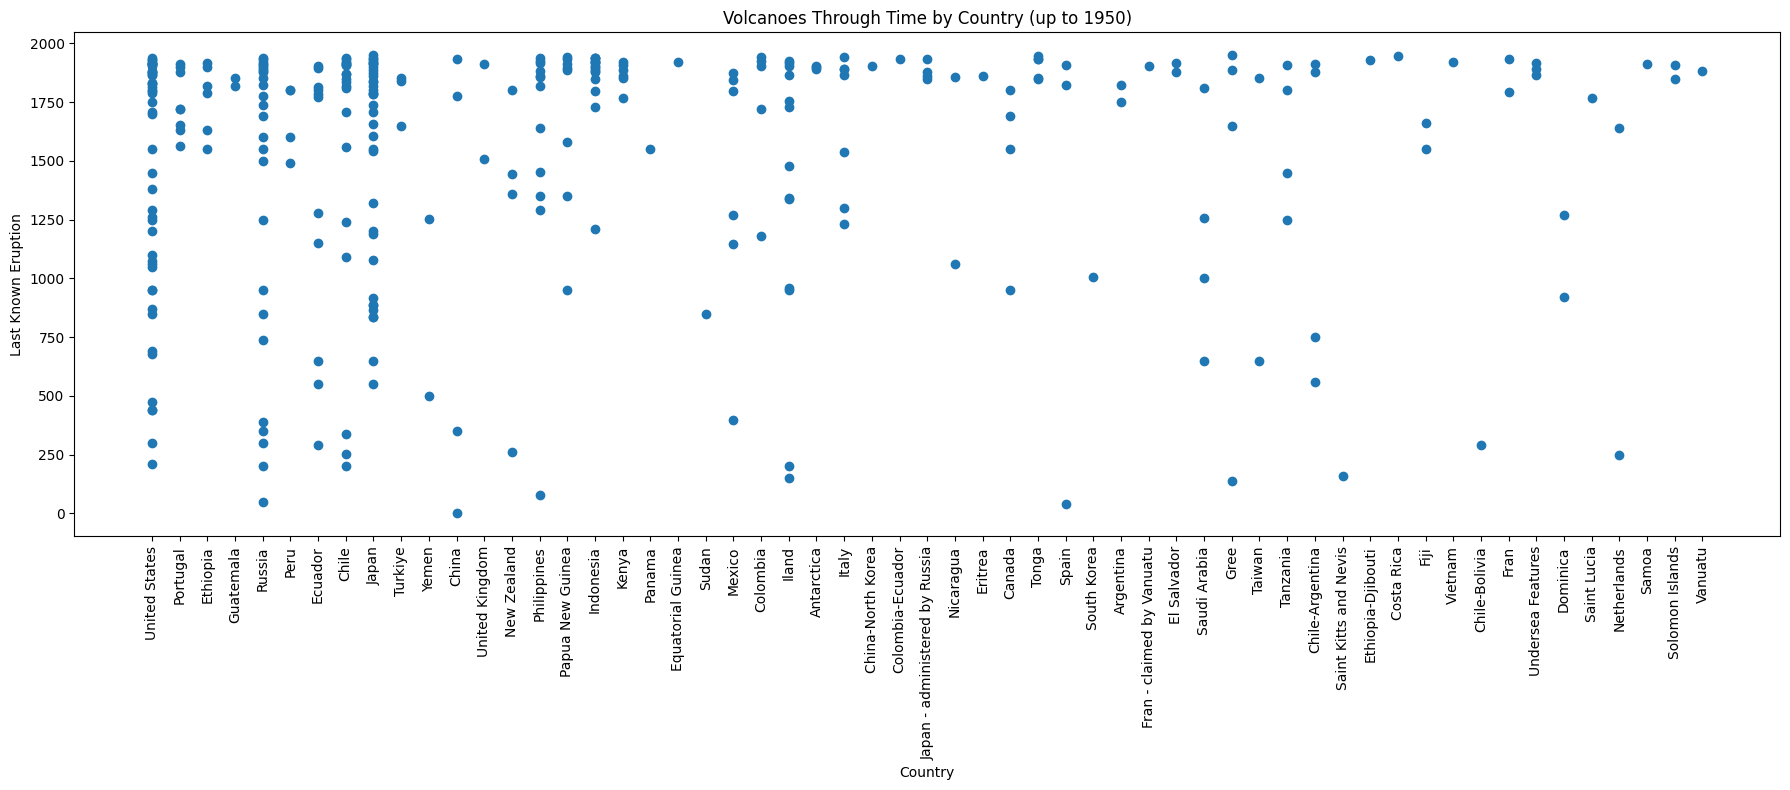

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_excel("VCLocsV2.xlsx")

# Filter for eruptions until 1950
df_filtered = df[df["Last Known Eruption"] <= 1950]

plt.figure(figsize=(18, 8))

# Create scatter plot
scatter = plt.scatter(
    df_filtered["Country"],
    df_filtered["Last Known Eruption"],
)

plt.xlabel("Country")
plt.ylabel("Last Known Eruption")
plt.title("Volcanoes Through Time by Country (up to 1950)")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import plotly.express as px

# Load data
df = pd.read_excel("VCLocsV2.xlsx")

# Clean eruption year
df["Last Known Eruption"] = pd.to_numeric(
    df["Last Known Eruption"],
    errors="coerce"
)

# Remove missing values
df = df.dropna(subset=["Country", "Last Known Eruption"])

# Create interactive scatter plot
fig = px.scatter(
    df,
    x="Last Known Eruption",
    y="Country",
    color="Country",
    hover_name="Volcano Name",
    hover_data={
        "Elevation (m)": True,
        "Primary Volcano Type": True,
        "Dominant Rock Type": True
    },
    title="Volcanoes Through Time by Country (Interactive)",
)

# Improve layout
fig.update_layout(
    xaxis_tickangle=-90,
    height=700,
    template="plotly_dark",
    showlegend=False
)

fig.show()

#**Erruption Coding and Analysis**

---




## **Visually Plotting Volcanic Erruptions on Earth** (8300BCE to 2026 AD)

####**Figure 1**: Volcanic Erruptions Across the Globe 8300BCE to 2026 AD

In [12]:
# Import packages
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

# Read Headings to check columns have the right name. With the amount of changes I made to my dataset throughout this process, this was the easiest way to make sure my code is running the right dataset
df = pd.read_excel("VCLocsV2.xlsx")
print(df.head(0))

Empty DataFrame
Columns: [Volcano Name, Country, Volcano Landform, Primary Volcano Type, Last Known Eruption, Latitude, Longitude, Elevation (m), Dominant Rock Type]
Index: []


In [13]:
# Constructing Figure 1 for Poster

# ============================================================
# LOAD DATA
# ============================================================

# Load without automatic headers
df = pd.read_excel(
    "VCLocsV2.xlsx",
    header=None
)

# Use first row as headers
df.columns = df.iloc[0]

# Remove header row from data
df = df[1:]

# Clean column names
df.columns = df.columns.str.strip()

# ============================================================
# KEEP REQUIRED COLUMNS
# ============================================================

df = df[[
    "Primary Volcano Type",
    "Latitude",
    "Longitude",
    "Volcano Landform",
    "Elevation (m)",
    "Dominant Rock Type",
    "Last Known Eruption"
]]

# ============================================================
# CLEAN DATA
# ============================================================

# Convert coordinates to numeric
df["Latitude"] = pd.to_numeric(
    df["Latitude"],
    errors="coerce"
)

df["Longitude"] = pd.to_numeric(
    df["Longitude"],
    errors="coerce"
)

# Convert elevation
df["Elevation (m)"] = pd.to_numeric(
    df["Elevation (m)"],
    errors="coerce"
)

# Remove invalid coordinates
df = df.dropna(subset=["Latitude", "Longitude"])

# ============================================================
# COLOUR MAPS
# ============================================================

volcano_types = df["Primary Volcano Type"].unique()

volcano_colours = {
    v: px.colors.qualitative.Dark24[i % 24]
    for i, v in enumerate(volcano_types)
}

# ============================================================
# CREATE FIGURE
# ============================================================

fig = go.Figure()

# ============================================================
# ADD VOLCANOES
# ============================================================

for vtype in volcano_types:

    subset = df[df["Primary Volcano Type"] == vtype]

    fig.add_trace(
        go.Scattergeo(

            lon=subset["Longitude"],
            lat=subset["Latitude"],

            mode="markers",

            marker=dict(
                size=8,
                color=volcano_colours[vtype],
                opacity=0.8
            ),

            # ====================================================
            # HOVER INFORMATION
            # ====================================================

            text=[
                f"""
                <b>Primary Volcano Type:</b> {vt}<br>
                <b>Volcano Landform:</b> {landform}<br>
                <b>Last Known Eruption:</b> {eruption}<br>
                <b>Latitude:</b> {lat}<br>
                <b>Longitude:</b> {lon}<br>
                <b>Elevation (m):</b> {elev}<br>
                <b>Dominant Rock Type:</b> {rock}
                """
                for vt, landform, eruption, lat, lon, elev, rock in zip(
                    subset["Primary Volcano Type"],
                    subset["Volcano Landform"],
                    subset["Last Known Eruption"],
                    subset["Latitude"],
                    subset["Longitude"],
                    subset["Elevation (m)"],
                    subset["Dominant Rock Type"]
                )
            ],

            hoverinfo="text",

            name=vtype
        )
    )

# ============================================================
# LAYOUT
# ============================================================

fig.update_layout(

    title="Global Volcano Erruptions, 8300BCE - 2026 AD (Figure 1)",

    height=850,

    geo=dict(

        projection_type="equirectangular",

        showland=True,
        landcolor="rgb(220,220,220)",

        showocean=True,
        oceancolor="rgb(180,210,255)",

        showcountries=True,
        countrycolor="gray",

        showcoastlines=True,
        coastlinecolor="black",

        showframe=False
    ),

    legend=dict(
        title="Primary Volcano Type"
    )
)

# ============================================================
# SHOW MAP
# ============================================================

fig.show()



---


## **Linearly Plotting Volcanic Erruptions Overtime**: Analysing Correlation


####**Figure 2**: Volcanic Erruptions Per-year 0BCE to 2026 AD

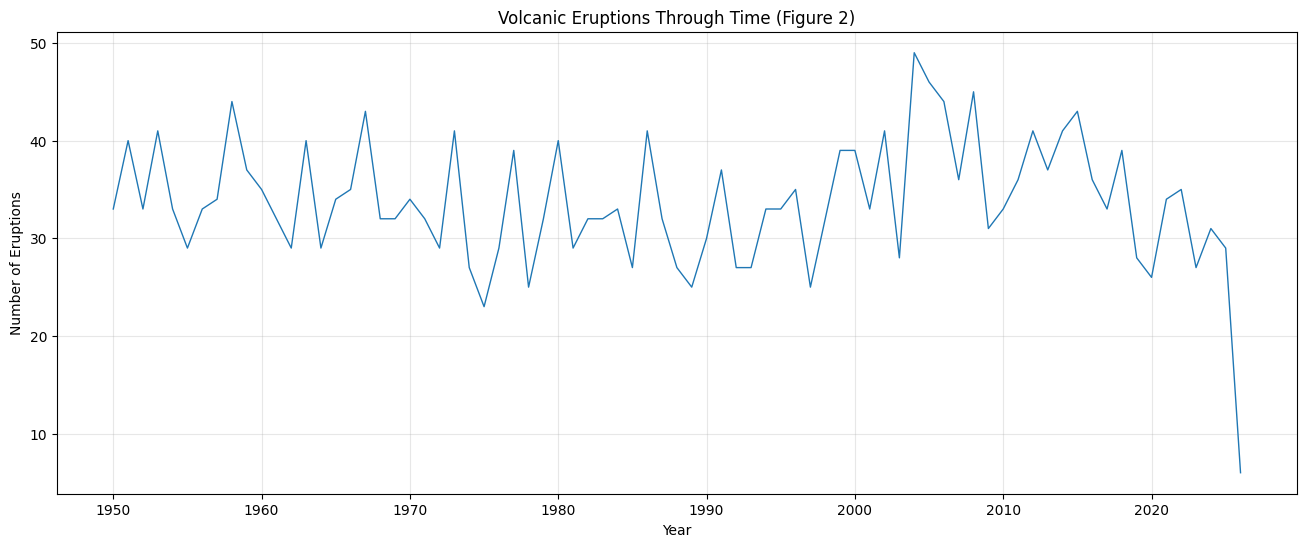

In [ ]:
#First Linear Plot: A general Plot of increase (n) of volcano Erruptions overtime

#Loading/Importing Dataset
df = pd.read_excel("VCErruptionsV2.xlsx")

# Cleaning Data and Converting years into numerical values

def convert_year(value):

    if pd.isna(value):
        return None

    value = str(value).strip()

    if value.lower() == "unknown":
        return None

    # BCE years → negative
    if "BCE" in value:
        num = re.findall(r"\d+", value)
        return -int(num[0]) if num else None

    # CE years → positive
    if "CE" in value:
        num = re.findall(r"\d+", value)
        return int(num[0]) if num else None

    # Plain numeric years
    if value.isdigit():
        return int(value)

    return None

# Apply conversion
df["Year"] = df["Start Year"].apply(convert_year)

# Remove Missing Years. Originally, I had this line to get rid of the volcanoes without years. However, I realised it woudl be better jus tot do this in my original dataset, as that would make it better in general too

#Count Erruptions-per-year to work out total increase overtime per-year

year_counts = (
    df_clean["Year"]
    .value_counts()
    .sort_index()
)

# CREATE FULL TIME SERIES

years = range(
    df_clean["Year"].min(),
    df_clean["Year"].max() + 1
)

counts = [
    year_counts.get(year, 0)
    for year in years
]

# Plotting Figure 2

plt.figure(figsize=(16,6))

plt.plot(
    years,
    counts,
    linewidth=1
)

plt.title("Volcanic Eruptions Through Time (Figure 2)")

plt.xlabel("Year")

plt.ylabel("Number of Eruptions")

plt.grid(alpha=0.3)

plt.show()

####**Figure 3**: Volcanic Erruptions Per-Year 1950-2026

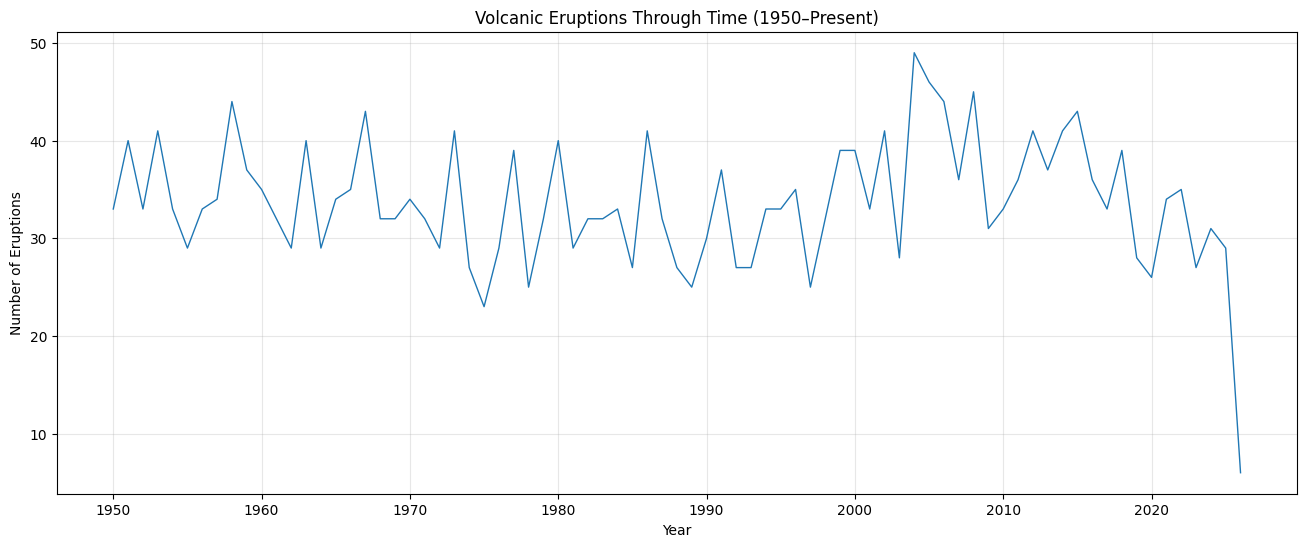

In [ ]:
#Plotting Figure 3: A shortened version of Figure 2, to only include data from 1950-2026

# ============================================================
# LOAD / IMPORT DATASET
# ============================================================

df = pd.read_excel("VCErruptionsV2.xlsx")

# ============================================================
# CLEAN DATA AND CONVERT YEARS
# ============================================================

def convert_year(value):

    if pd.isna(value):
        return None

    value = str(value).strip()

    if value.lower() == "unknown":
        return None

    # BCE years → negative
    if "BCE" in value:
        num = re.findall(r"\d+", value)
        return -int(num[0]) if num else None

    # CE years → positive
    if "CE" in value:
        num = re.findall(r"\d+", value)
        return int(num[0]) if num else None

    # Plain numeric years
    if value.isdigit():
        return int(value)

    return None

# Apply conversion
df["Year"] = df["Start Year"].apply(convert_year)

# ============================================================
# REMOVE MISSING YEARS
# ============================================================

df_clean = df.dropna(subset=["Year"])

# Convert to integer
df_clean["Year"] = df_clean["Year"].astype(int)

# ============================================================
# FILTER YEARS (1950 ONWARDS)
# ============================================================

df_clean = df_clean[df_clean["Year"] >= 1950]

# ============================================================
# COUNT ERUPTIONS PER YEAR
# ============================================================

year_counts = (
    df_clean["Year"]
    .value_counts()
    .sort_index()
)

# ============================================================
# CREATE TIME SERIES
# ============================================================

years = range(
    1950,
    df_clean["Year"].max() + 1
)

counts = [
    year_counts.get(year, 0)
    for year in years
]

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(16,6))

plt.plot(
    years,
    counts,
    linewidth=1
)

plt.title("Volcanic Eruptions Through Time (1950–Present)")

plt.xlabel("Year")

plt.ylabel("Number of Eruptions")

plt.grid(alpha=0.3)

plt.show()

####**Interpreting Figures 2 and 3:** Explaining and Interpreting the Erruption Increase in 2026

The increase in 2026 is not a real spike in volcanic activity but a consequence of how the dataset records ongoing eruptions. For volcanoes that remain active over multiple years, the “Last Known Eruption” field is often updated to the most recent observation year, meaning many long-duration or persistently active volcanoes are assigned the current year (2026 CE). As a result, eruptions that have been occurring or intermittently active over time all get grouped into the same final year rather than being distributed across their actual eruption timeline. This creates an artificial concentration of values in the most recent year and inflates the apparent number of eruptions in 2026, even though it mainly reflects reporting and updating conventions rather than a genuine increase in volcanic activity.

#### Ways we can prevent this from impacting our data

1.  Remove 2026 values entirely if they are being used as a placeholder for ongoing activity rather than a true eruption year, which prevents artificial clustering.
2. Treat these entries separately by distinguishing between historical eruptions and ongoing or recently active volcanoes, rather than combining them in the same dataset.
1.   Improve accuracy by using full eruption histories instead of just the “last known eruption” field
2.   Group data into larger time intervals, such as decades, which reduces noise and smooths out reporting artefacts

####**Figures (4.1, 4.2, 4.3, 4.4 and 4.5)**: Experimenting with Different methods of cleaning data to remove 2026 issues

/tmp/ipykernel_30510/4213035974.py:65: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



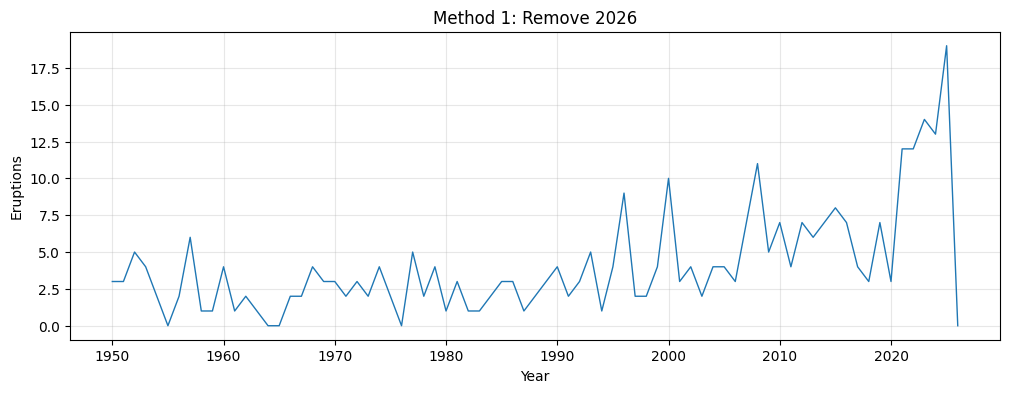

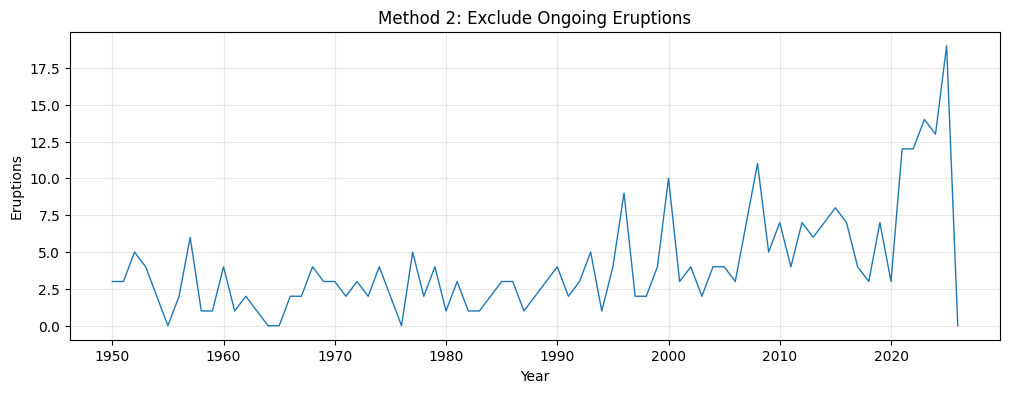

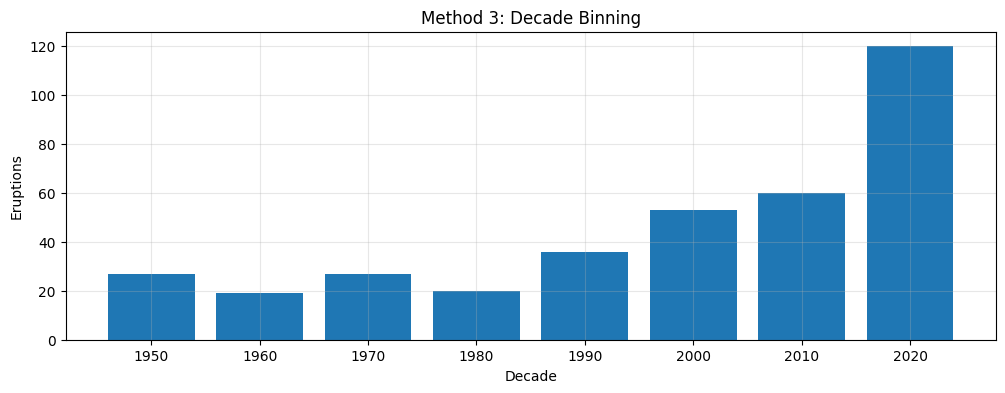

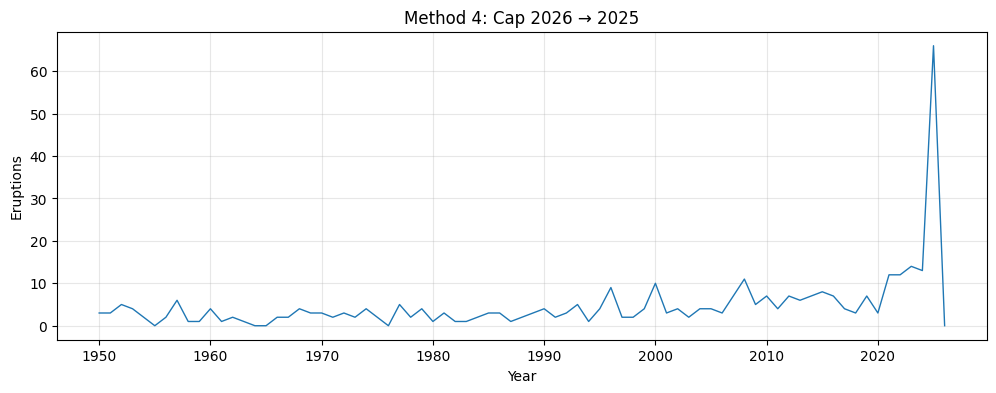

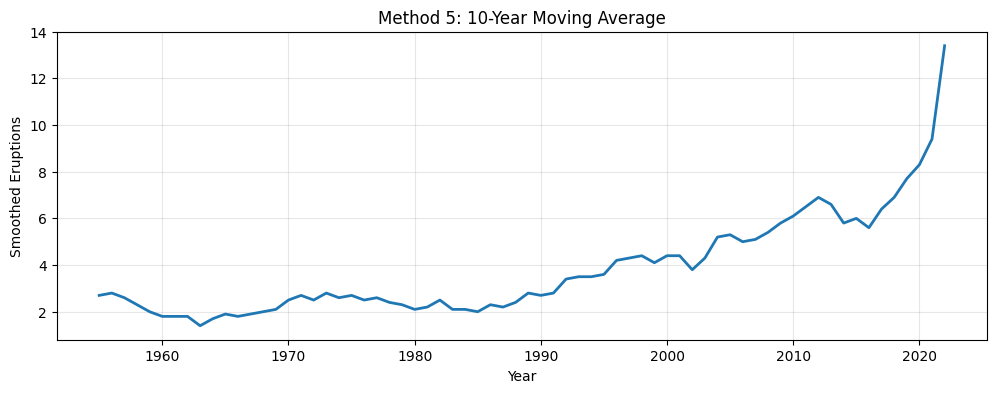

In [ ]:
# ============================================================
# VOLCANIC ERUPTION TIME SERIES ANALYSIS
# ALL DATA FILTERED TO 1950–2026
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import re

# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_excel("VCLocs.xls", header=None)

# Use first row as headers
df.columns = df.iloc[0]

# Remove header row
df = df[1:]

# Clean column names
df.columns = df.columns.str.strip()

# ============================================================
# EXTRACT ERUPTION COLUMN
# ============================================================

y = df["Last Known Eruption"]

# ============================================================
# CLEAN FUNCTION
# ============================================================

def convert_year(value):

    if pd.isna(value):
        return None

    value = str(value).strip()

    if value.lower() == "unknown":
        return None

    # Convert CE years only
    if "CE" in value:

        num = re.findall(r"\d+", value)

        return int(num[0]) if num else None

    # Ignore BCE
    return None

# Apply conversion
df["Year"] = y.apply(convert_year)

# ============================================================
# REMOVE MISSING YEARS
# ============================================================

df_clean = df.dropna(subset=["Year"])

# Convert to integer
df_clean["Year"] = df_clean["Year"].astype(int)

# ============================================================
# FILTER YEARS: 1950–2026 ONLY
# ============================================================

df_clean = df_clean[
    (df_clean["Year"] >= 1950) &
    (df_clean["Year"] <= 2026)
]

# ============================================================
# METHOD 1 — REMOVE 2026
# ============================================================

df_no_2026 = df_clean[
    df_clean["Year"] != 2026
]

# ============================================================
# METHOD 2 — SEPARATE ONGOING
# ============================================================

df_ongoing = df_clean[
    df_clean["Year"] == 2026
]

df_historical = df_clean[
    df_clean["Year"] != 2026
]

# ============================================================
# METHOD 3 — DECADE BINNING
# ============================================================

df_decade = df_clean.copy()

df_decade["Decade"] = (
    df_decade["Year"] // 10
) * 10

decade_counts = (
    df_decade["Decade"]
    .value_counts()
    .sort_index()
)

# ============================================================
# METHOD 4 — CAP 2026 → 2025
# ============================================================

df_capped = df_clean.copy()

df_capped["Year"] = (
    df_capped["Year"]
    .replace(2026, 2025)
)

# ============================================================
# METHOD 5 — MOVING AVERAGE
# ============================================================

year_counts_raw = (
    df_clean["Year"]
    .value_counts()
    .sort_index()
)

years = range(1950, 2027)

counts_raw = [
    year_counts_raw.get(y, 0)
    for y in years
]

rolling_avg = (
    pd.Series(counts_raw)
    .rolling(window=10, center=True)
    .mean()
)

# ============================================================
# PLOTTING FUNCTION
# ============================================================

def plot_data(title, years, counts):

    plt.figure(figsize=(12,4))

    plt.plot(
        years,
        counts,
        linewidth=1
    )

    plt.title(title)

    plt.xlabel("Year")

    plt.ylabel("Eruptions")

    plt.grid(alpha=0.3)

    plt.show()

# ============================================================
# METHOD 1 — REMOVE 2026
# ============================================================

counts1 = (
    df_no_2026["Year"]
    .value_counts()
    .sort_index()
)

plot_data(
    "Method 1: Remove 2026",
    years,
    [counts1.get(y, 0) for y in years]
)

# ============================================================
# METHOD 2 — EXCLUDE ONGOING
# ============================================================

counts2 = (
    df_historical["Year"]
    .value_counts()
    .sort_index()
)

plot_data(
    "Method 2: Exclude Ongoing Eruptions",
    years,
    [counts2.get(y, 0) for y in years]
)

# ============================================================
# METHOD 3 — DECADE BINNING
# ============================================================

plt.figure(figsize=(12,4))

plt.bar(
    decade_counts.index,
    decade_counts.values,
    width=8
)

plt.title("Method 3: Decade Binning")

plt.xlabel("Decade")

plt.ylabel("Eruptions")

plt.grid(alpha=0.3)

plt.show()

# ============================================================
# METHOD 4 — CAP 2026 → 2025
# ============================================================

counts4 = (
    df_capped["Year"]
    .value_counts()
    .sort_index()
)

plot_data(
    "Method 4: Cap 2026 → 2025",
    years,
    [counts4.get(y, 0) for y in years]
)

# ============================================================
# METHOD 5 — MOVING AVERAGE
# ============================================================

plt.figure(figsize=(12,4))

plt.plot(
    years,
    rolling_avg,
    linewidth=2
)

plt.title("Method 5: 10-Year Moving Average")

plt.xlabel("Year")

plt.ylabel("Smoothed Eruptions")

plt.grid(alpha=0.3)

plt.show()

####**Interpreting Figures (4.1, 4.2, 4.3, 4.4 and 4.5)**

####**Figure 5.1**: Plotting Regression of Volcanic Erruptions Per Year (1950-2026)
**Time Series Analysis (Week 10)**
Time series analysis will be used to study how volcanic eruptions change through time. Eruptions will be counted by year and plotted on line graphs to identify patterns in eruption frequency. Moving averages and rolling means will be used to smooth the data and highlight periods of high or low activity. The results will then be analysed to determine whether eruptions occur randomly or  in temporal clusters.

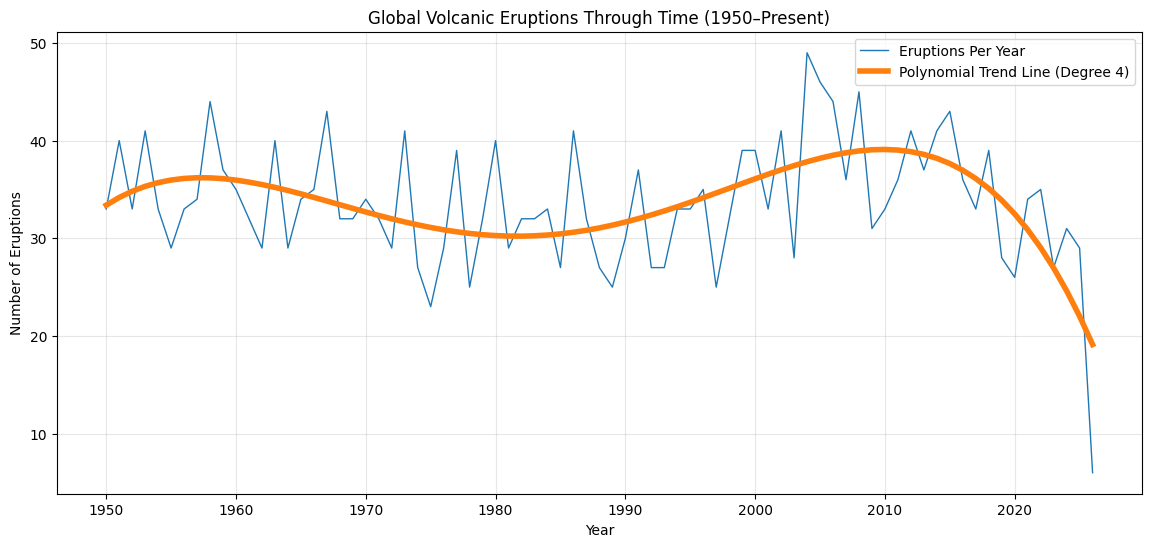

In [16]:
#add uncertainty

# ============================================================
# TIME SERIES ANALYSIS OF GLOBAL VOLCANIC ERUPTIONS
# WITH IMPROVED TREND LINE
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_excel("VCErrupt1950.xlsx")

# ============================================================
# CLEAN / CONVERT YEARS
# ============================================================

def convert_year(value):

    if pd.isna(value):
        return None

    value = str(value).strip()

    if value.lower() == "unknown":
        return None

    # BCE years
    if "BCE" in value:
        num = re.findall(r"\d+", value)
        return -int(num[0]) if num else None

    # CE years
    if "CE" in value:
        num = re.findall(r"\d+", value)
        return int(num[0]) if num else None

    # Plain numeric years
    if value.isdigit():
        return int(value)

    return None

# Apply conversion
df["Year"] = df["Start Year"].apply(convert_year)

# Remove missing years
df_clean = df.dropna(subset=["Year"])

# Convert to integer
df_clean["Year"] = df_clean["Year"].astype(int)

# ============================================================
# FILTER YEARS (1950 ONWARDS)
# ============================================================

df_clean = df_clean[df_clean["Year"] >= 1950]

# ============================================================
# COUNT ERUPTIONS PER YEAR
# ============================================================

eruption_counts = (
    df_clean["Year"]
    .value_counts()
    .sort_index()
)

# ============================================================
# CREATE COMPLETE TIME SERIES
# ============================================================

all_years = np.arange(
    1950,
    df_clean["Year"].max() + 1
)

all_counts = np.array([
    eruption_counts.get(year, 0)
    for year in all_years
])

# ============================================================
# CREATE DATAFRAME
# ============================================================

time_series = pd.DataFrame({
    "Year": all_years,
    "Eruptions": all_counts
})

# ============================================================
# POLYNOMIAL TREND LINE
# ============================================================

# Lower degree avoids extreme overfitting
degree = 4

z = np.polyfit(
    time_series["Year"],
    time_series["Eruptions"],
    degree
)

p = np.poly1d(z)

trendline = p(time_series["Year"])

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(14,6))

# Raw eruption counts
plt.plot(
    time_series["Year"],
    time_series["Eruptions"],
    linewidth=1,
    label="Eruptions Per Year"
)

# Trend line
plt.plot(
    time_series["Year"],
    trendline,
    linewidth=4,
    label=f"Polynomial Trend Line (Degree {degree})"
)

# Labels
plt.xlabel("Year")

plt.ylabel("Number of Eruptions")

plt.title(
    "Global Volcanic Eruptions Through Time (1950–Present)"
)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

####**Figure 5.2**: Plotting Regression of Volcanic Erruptions Per Year. Finding best polynomial fit (1950-2026)


In [17]:
!pip install bambi pymc arviz

Fitting 0-order model...


Output()

/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning:

Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.



Fitting 1st-order model...


Output()

...

/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning:

Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.



Fitting 4th-order model...


Output()

/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning:

Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.

/usr/local/lib/python3.12/dist-packages/arviz_stats/loo/helper_loo.py:1146: UserWarning:

Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.

/usr/local/lib/python3.12/dist-packages/arviz_stats/loo/helper_loo.py:1146: UserWarning:

Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal post


MODEL COMPARISON
           rank   elpd    p  elpd_diff  weight    se  dse  warning
4th-order     0 -240.0  6.6        0.0    0.96   6.0  0.0     True
3rd-order     1 -250.0  6.1       -7.0    0.00   8.0  4.1    False
0-order       2 -260.0  3.6      -10.0    0.04  11.0  7.1     True
1st-order     3 -260.0  4.3      -10.0    0.00  11.0  6.8     True
2nd-order     4 -260.0  5.7      -10.0    0.00  11.0  6.9     True

Best model:
4th-order


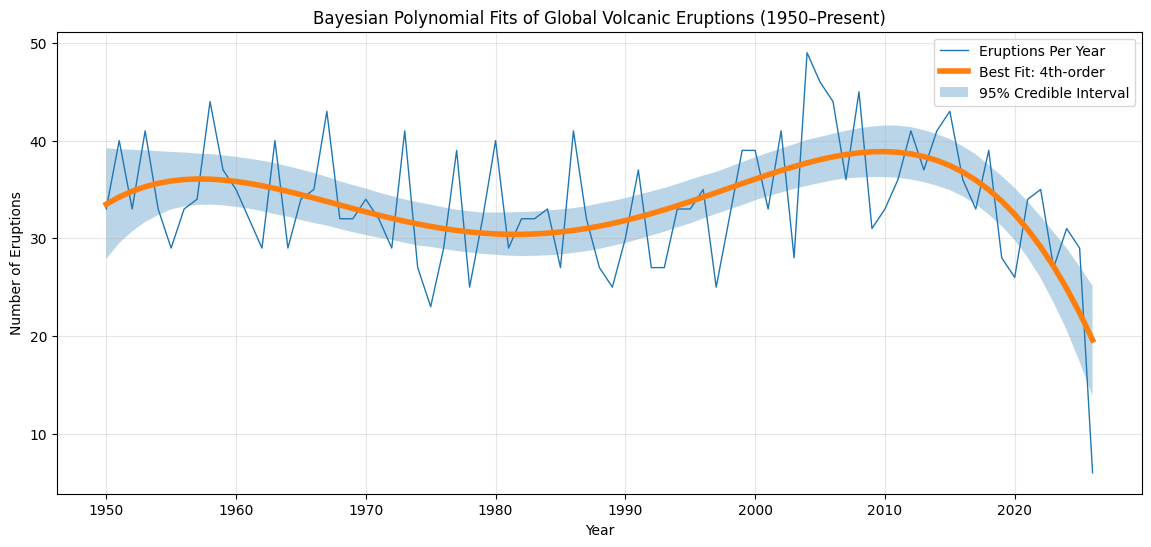

In [18]:
# ============================================================
# BAYESIAN POLYNOMIAL MODEL COMPARISON
# GLOBAL VOLCANIC ERUPTIONS THROUGH TIME
# ============================================================

# ============================================================
# INSTALL PACKAGES (RUN ONCE)
# ============================================================

# !pip install bambi pymc arviz openpyxl

# ============================================================
# IMPORTS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

import bambi as bmb
import arviz as az

# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_excel("VCErrupt1950.xlsx")

# ============================================================
# CLEAN / CONVERT YEARS
# ============================================================

def convert_year(value):

    if pd.isna(value):
        return None

    value = str(value).strip()

    if value.lower() == "unknown":
        return None

    # BCE years
    if "BCE" in value:
        num = re.findall(r"\d+", value)
        return -int(num[0]) if num else None

    # CE years
    if "CE" in value:
        num = re.findall(r"\d+", value)
        return int(num[0]) if num else None

    # Plain numeric years
    if value.isdigit():
        return int(value)

    return None

# Apply conversion
df["Year"] = df["Start Year"].apply(convert_year)

# Remove missing years
df_clean = df.dropna(subset=["Year"]).copy()

# Convert to integer
df_clean["Year"] = df_clean["Year"].astype(int)

# ============================================================
# FILTER YEARS (1950 ONWARDS)
# ============================================================

df_clean = df_clean[df_clean["Year"] >= 1950]

# ============================================================
# COUNT ERUPTIONS PER YEAR
# ============================================================

eruption_counts = (
    df_clean["Year"]
    .value_counts()
    .sort_index()
)

# ============================================================
# CREATE COMPLETE TIME SERIES
# ============================================================

all_years = np.arange(
    1950,
    df_clean["Year"].max() + 1
)

all_counts = np.array([
    eruption_counts.get(year, 0)
    for year in all_years
])

# ============================================================
# CREATE DATAFRAME
# ============================================================

time_series = pd.DataFrame({
    "Year": all_years,
    "Eruptions": all_counts
})

# ============================================================
# SCALE YEARS
# IMPORTANT FOR POLYNOMIAL STABILITY
# ============================================================

time_series["x"] = (
    time_series["Year"] - time_series["Year"].mean()
) / time_series["Year"].std()

# Polynomial terms
time_series["x2"] = time_series["x"]**2
time_series["x3"] = time_series["x"]**3
time_series["x4"] = time_series["x"]**4

# ============================================================
# FIT MODELS
# ============================================================

print("Fitting 0-order model...")

model0 = bmb.Model(
    "Eruptions ~ 1",
    time_series
)

idata0 = model0.fit(
    draws=1000,
    tune=1000,
    target_accept=0.95,
    idata_kwargs={"log_likelihood": True}
)

# ------------------------------------------------------------

print("Fitting 1st-order model...")

model1 = bmb.Model(
    "Eruptions ~ x",
    time_series
)

idata1 = model1.fit(
    draws=1000,
    tune=1000,
    target_accept=0.95,
    idata_kwargs={"log_likelihood": True}
)

# ------------------------------------------------------------

print("Fitting 2nd-order model...")

model2 = bmb.Model(
    "Eruptions ~ x + x2",
    time_series
)

idata2 = model2.fit(
    draws=1000,
    tune=1000,
    target_accept=0.95,
    idata_kwargs={"log_likelihood": True}
)

# ------------------------------------------------------------

print("Fitting 3rd-order model...")

model3 = bmb.Model(
    "Eruptions ~ x + x2 + x3",
    time_series
)

idata3 = model3.fit(
    draws=1000,
    tune=1000,
    target_accept=0.95,
    idata_kwargs={"log_likelihood": True}
)

# ------------------------------------------------------------

print("Fitting 4th-order model...")

model4 = bmb.Model(
    "Eruptions ~ x + x2 + x3 + x4",
    time_series
)

idata4 = model4.fit(
    draws=1000,
    tune=1000,
    target_accept=0.95,
    idata_kwargs={"log_likelihood": True}
)

# ============================================================
# MODEL COMPARISON
# ============================================================

comparison = az.compare(
    {
        "0-order": idata0,
        "1st-order": idata1,
        "2nd-order": idata2,
        "3rd-order": idata3,
        "4th-order": idata4
    }
)

print("\n================================================")
print("MODEL COMPARISON")
print("================================================")

print(comparison)

# ============================================================
# SELECT BEST MODEL
# ============================================================

best_model_name = comparison.index[0]

print("\nBest model:")
print(best_model_name)

# ============================================================
# CHOOSE BEST MODEL
# ============================================================

if best_model_name == "0-order":
    model_best = model0
    idata_best = idata0

elif best_model_name == "1st-order":
    model_best = model1
    idata_best = idata1

elif best_model_name == "2nd-order":
    model_best = model2
    idata_best = idata2

elif best_model_name == "3rd-order":
    model_best = model3
    idata_best = idata3

else:
    model_best = model4
    idata_best = idata4

# ============================================================
# GENERATE POSTERIOR PREDICTIONS
# ============================================================

predictions = model_best.predict(
    idata_best,
    kind="mean",
    inplace=False
)

# Extract posterior predictions
posterior = predictions.posterior["mu"].values

# Mean prediction
mean_pred = posterior.mean(axis=(0, 1))

# 95% credible interval
lower = np.percentile(
    posterior,
    2.5,
    axis=(0, 1)
)

upper = np.percentile(
    posterior,
    97.5,
    axis=(0, 1)
)

# ============================================================
# PLOT RESULTS
# ============================================================

plt.figure(figsize=(14, 6))

# Raw eruption counts
plt.plot(
    time_series["Year"],
    time_series["Eruptions"],
    linewidth=1,
    label="Eruptions Per Year"
)

# Bayesian fit
plt.plot(
    time_series["Year"],
    mean_pred,
    linewidth=4,
    label=f"Best Fit: {best_model_name}"
)

# Uncertainty interval
plt.fill_between(
    time_series["Year"],
    lower,
    upper,
    alpha=0.3,
    label="95% Credible Interval"
)

# Labels
plt.xlabel("Year")
plt.ylabel("Number of Eruptions")

plt.title(
    "Bayesian Polynomial Fits of Global Volcanic Eruptions (1950–Present)"
)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

####**Interpeting Figure 5**

####**Figure 6**: Plotting Regression of Volcanic Erruptions Per Year (1950-2026)


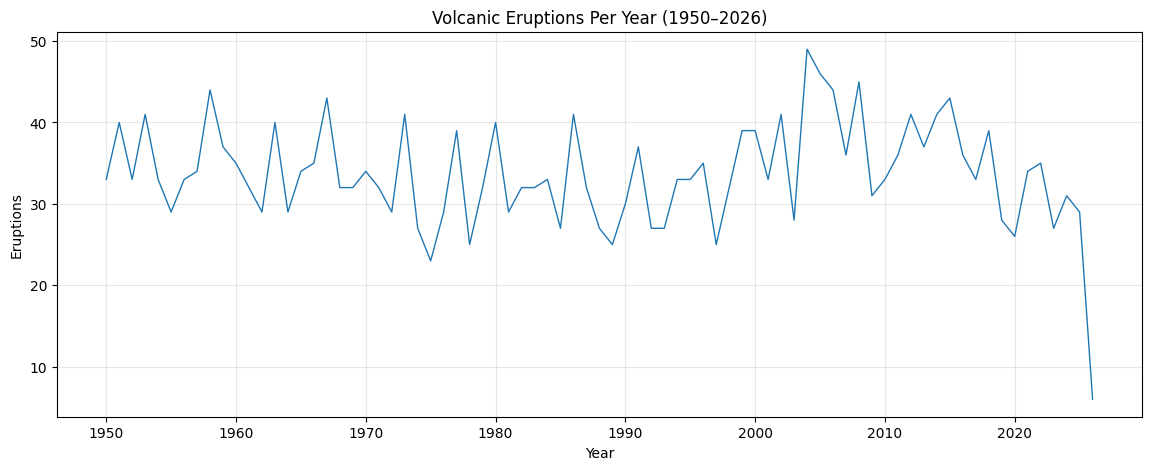

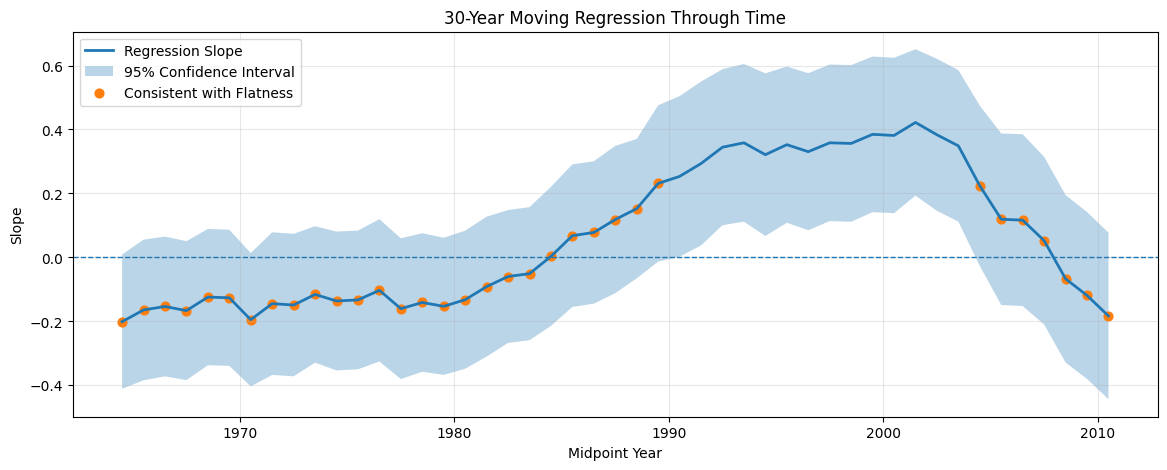

Flat behaviour begins approximately around 1964.


In [ ]:
# ============================================================
# 0TH vs 1ST ORDER MODEL TEST
# MOVING 30-YEAR REGRESSION
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
from scipy.stats import linregress

# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_excel("VCErruptionsV2.xlsx")

# ============================================================
# CLEAN YEARS
# ============================================================

def convert_year(value):

    if pd.isna(value):
        return None

    value = str(value).strip()

    if value.lower() == "unknown":
        return None

    if "CE" in value:
        num = re.findall(r"\d+", value)
        return int(num[0]) if num else None

    if value.isdigit():
        return int(value)

    return None

df["Year"] = df["Start Year"].apply(convert_year)

# ============================================================
# CLEAN DATA
# ============================================================

df_clean = df.dropna(subset=["Year"])

df_clean["Year"] = df_clean["Year"].astype(int)

df_clean = df_clean[
    (df_clean["Year"] >= 1950) &
    (df_clean["Year"] <= 2026)
]

# ============================================================
# COUNT ERUPTIONS PER YEAR
# ============================================================

year_counts = (
    df_clean["Year"]
    .value_counts()
    .sort_index()
)

years = np.arange(1950, 2027)

counts = np.array([
    year_counts.get(y, 0)
    for y in years
])

# ============================================================
# MOVING 30-YEAR REGRESSION
# ============================================================

window = 30

mid_years = []

slopes = []
slope_errors = []

flat_flags = []

for start in range(len(years) - window):

    x = years[start:start + window]
    y = counts[start:start + window]

    result = linregress(x, y)

    slope = result.slope
    stderr = result.stderr

    mid_year = x.mean()

    mid_years.append(mid_year)

    slopes.append(slope)

    slope_errors.append(stderr)

    # ========================================================
    # TEST IF SLOPE CONSISTENT WITH ZERO
    # ========================================================

    lower = slope - 2 * stderr
    upper = slope + 2 * stderr

    # If 95% interval overlaps 0:
    flat = (lower <= 0 <= upper)

    flat_flags.append(flat)

# ============================================================
# PLOT 1 — ERUPTIONS THROUGH TIME
# ============================================================

plt.figure(figsize=(14,5))

plt.plot(
    years,
    counts,
    linewidth=1
)

plt.title(
    "Volcanic Eruptions Per Year (1950–2026)"
)

plt.xlabel("Year")

plt.ylabel("Eruptions")

plt.grid(alpha=0.3)

plt.show()

# ============================================================
# PLOT 2 — MOVING SLOPE ANALYSIS
# ============================================================

plt.figure(figsize=(14,5))

# slope
plt.plot(
    mid_years,
    slopes,
    linewidth=2,
    label="Regression Slope"
)

# uncertainty band
slopes = np.array(slopes)
slope_errors = np.array(slope_errors)

plt.fill_between(
    mid_years,
    slopes - 2*slope_errors,
    slopes + 2*slope_errors,
    alpha=0.3,
    label="95% Confidence Interval"
)

# zero line
plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

# highlight flat regions
flat_x = [
    x for x, f in zip(mid_years, flat_flags)
    if f
]

flat_y = [
    y for y, f in zip(slopes, flat_flags)
    if f
]

plt.scatter(
    flat_x,
    flat_y,
    s=40,
    label="Consistent with Flatness"
)

plt.title(
    "30-Year Moving Regression Through Time"
)

plt.xlabel("Midpoint Year")

plt.ylabel("Slope")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

# ============================================================
# PRINT FLAT INTERVALS
# ============================================================

if any(flat_flags):

    first_flat = flat_x[0]

    print(
        f"Flat behaviour begins approximately around {first_flat:.0f}."
    )

else:

    print(
        "No interval statistically consistent with flatness."
    )

####**Interpreting Figure 6**


#**Erruption Final Analysis and Reflection**
---

##**Final Analysis**



##**Reflection**
